# Tutorial clasificador MIMLBRkNN

In [1]:
import sys
from pathlib import Path

sys.path.insert(
    0,
    str(Path.home() / "GitHub" / "MIML" / "src")
)
output_path = str(Path.home() / "GitHub" / "MIML" / "src" / "miml" / "tutorial")

from miml.data import load_dataset

import miml

print(miml.__file__)

/home/juanjo/GitHub/MIML/src/miml/__init__.py


# Install dependencies

In [2]:
%pip install numpy pandas scikit-learn matplotlib seaborn 

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


# Import metrics, classifier and Hausdorff distances

In [3]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    hamming_loss,
)

# Add the project source directory to Python's path.
sys.path.insert(
    0,
    str(Path.home() / "GitHub" / "MIML" / "src"),
)

from miml.data import load_dataset
from miml.report import Report

from miml.classifier.miml.lazy.miml_dgc import MIMLDGC

from miml.core.average_hausdorff import AverageHausdorff
from miml.core.maximal_hausdorff import MaximalHausdorff
from miml.core.minimal_hausdorff import MinimalHausdorff

# Load datasets

In [4]:
birds = load_dataset(
    "miml_birds.arff",
    from_library=True,
)

birds_train, birds_test = birds.split_dataset(
    train_percentage=0.8,
    seed=7,
)


# text = load_dataset(
#     "miml_text_data.arff",
#     from_library=True,
# )

# text_train, text_test = text.split_dataset(
#     train_percentage=0.8,
#     seed=7,
# )


image = load_dataset(
    "miml_image_data.arff",
    from_library=True,
)

image_train, image_test = image.split_dataset(
    train_percentage=0.8,
    seed=7,
)

datasets = {
    "birds": (birds_train, birds_test),
    # "text": (text_train, text_test),
    "image": (image_train, image_test),
}

# Add Algorithms and distances to list

In [5]:
algorithms = {
    "MIMLDGC": MIMLDGC,
}


distances = {
    "AverageHausdorff": AverageHausdorff(),
    "MaximalHausdorff": MaximalHausdorff(),
    "MinimalHausdorff": MinimalHausdorff(),
}

# Add method to load algorithm

In [6]:
def create_classifiers(metric):
    return {
        "MIMLDGC": MIMLDGC(
            metric=metric,
            num_of_neighbours=10,
        ),
    }

# Run algorithm and save results in table

In [7]:
log_cols=["Dataset", "Distance", "Subset Accuracy", "Accuracy", "F1 Score Macro", "F1 Score Micro", "Hamming Loss"]
log = pd.DataFrame({
    "Dataset": pd.Series(dtype="object"),
    "Distance": pd.Series(dtype="object"),
    "Subset Accuracy": pd.Series(dtype="float64"),
    "Accuracy": pd.Series(dtype="float64"),
    "F1 Score Macro": pd.Series(dtype="float64"),
    "F1 Score Micro": pd.Series(dtype="float64"),
    "Hamming Loss": pd.Series(dtype="float64"),
})

for dataset_name, (dataset_train, dataset_test) in datasets.items():

    for distance_name, distance in distances.items():

        classifiers = create_classifiers(distance)

        for classifier_name, classifier in classifiers.items():

            classifier.build(dataset_train)
            y_pred = classifier.evaluate(dataset_test)
            probs = classifier.predict_proba(dataset_test)

            report = Report(y_pred, probs, dataset_test)
            report.calculate_metrics()    
            log_entry = pd.DataFrame([[dataset_name, distance_name, report.metrics_value["subset-accuracy-score"], report.metrics_value["accuracy-score"], report.metrics_value["f1-score-macro"], report.metrics_value["f1-score-micro"], report.metrics_value["hamming-loss"]]], columns=log_cols)
            log = pd.concat([log, log_entry], ignore_index=True)

# Show results

In [8]:
results_df = pd.DataFrame(log)
results_df

,Dataset,Distance,Subset Accuracy,Accuracy,F1 Score Macro,F1 Score Micro,Hamming Loss
0,birds,AverageHausdorff,0.058824,0.110131,0.048543,0.174603,0.107327
1,birds,MaximalHausdorff,0.098039,0.170588,0.074417,0.214765,0.120743
2,birds,MinimalHausdorff,0.117647,0.226144,0.124115,0.278146,0.112487
3,image,AverageHausdorff,0.397500,0.428750,0.292105,0.485564,0.196000
4,image,MaximalHausdorff,0.267500,0.297917,0.257514,0.367911,0.228500
5,image,MinimalHausdorff,0.255000,0.288333,0.241132,0.362360,0.227000


In [9]:
results_df.round(4)

,Dataset,Distance,Subset Accuracy,Accuracy,F1 Score Macro,F1 Score Micro,Hamming Loss
0,birds,AverageHausdorff,0.0588,0.1101,0.0485,0.1746,0.1073
1,birds,MaximalHausdorff,0.0980,0.1706,0.0744,0.2148,0.1207
2,birds,MinimalHausdorff,0.1176,0.2261,0.1241,0.2781,0.1125
3,image,AverageHausdorff,0.3975,0.4288,0.2921,0.4856,0.1960
4,image,MaximalHausdorff,0.2675,0.2979,0.2575,0.3679,0.2285
5,image,MinimalHausdorff,0.2550,0.2883,0.2411,0.3624,0.2270


# Save results in csv file

In [ ]:
results_path = Path(output_path) / "MIMLGDC_experiments.csv"

results_df.to_csv(
    results_path,
    index=False,
)

print(f"Results saved to: {results_path}")

Results saved to: /home/juanjo/GitHub/MIML/src/miml/tutorial/MIMLBRkNN_experiments.csv


# Show results in graphics

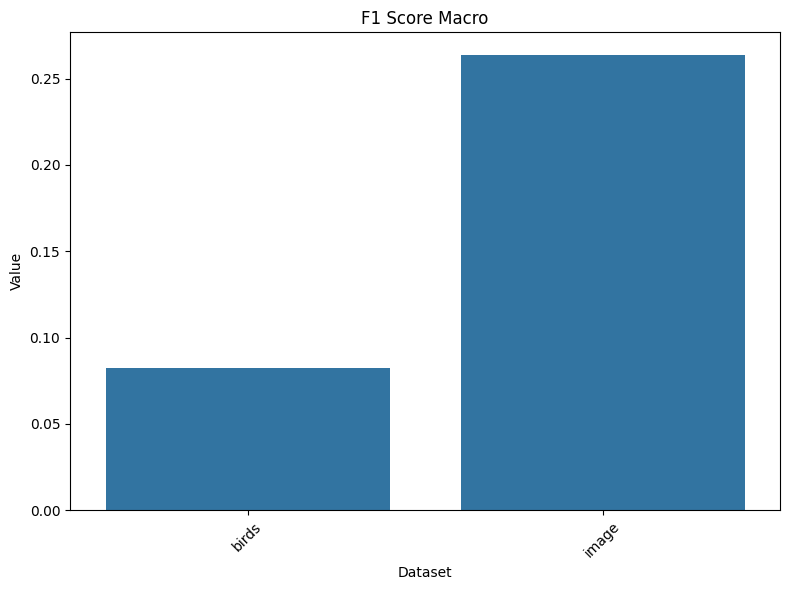

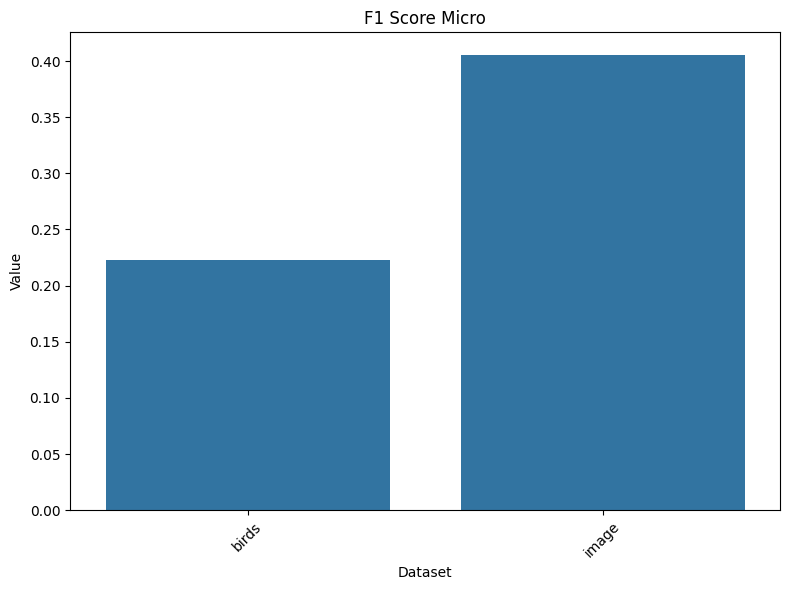

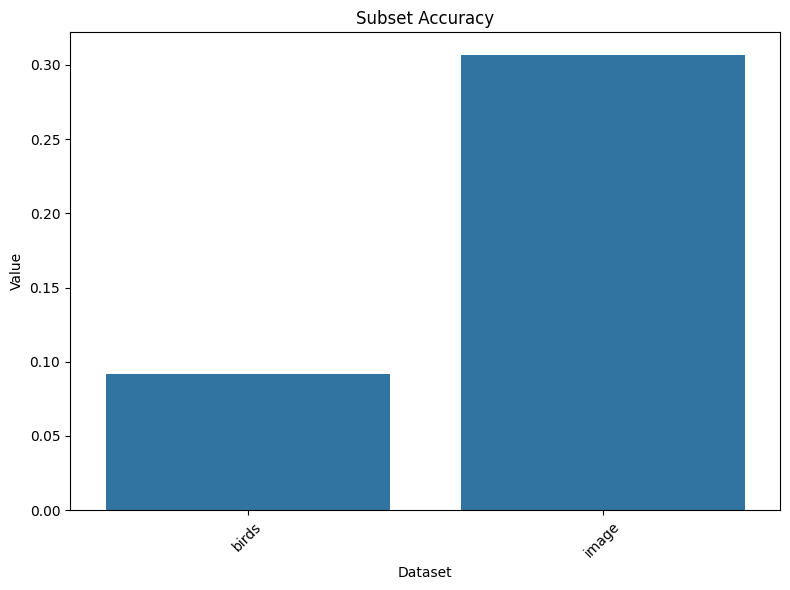

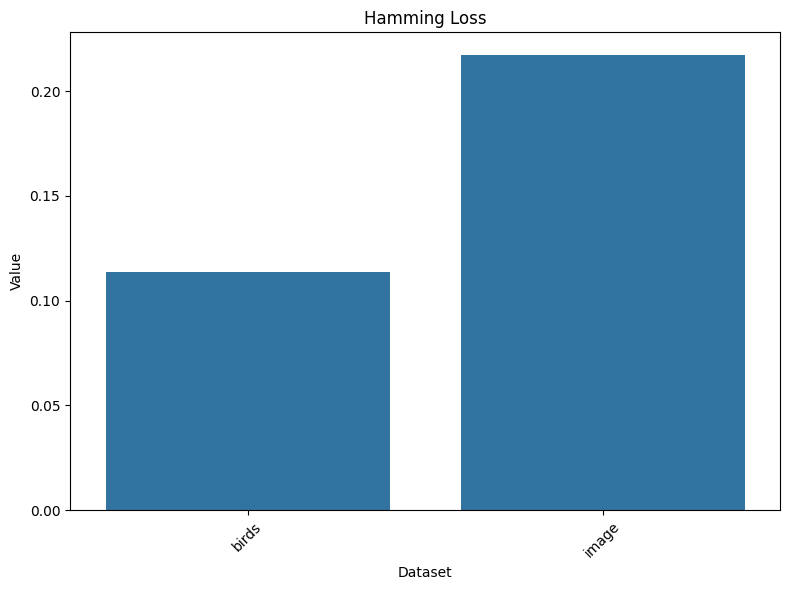

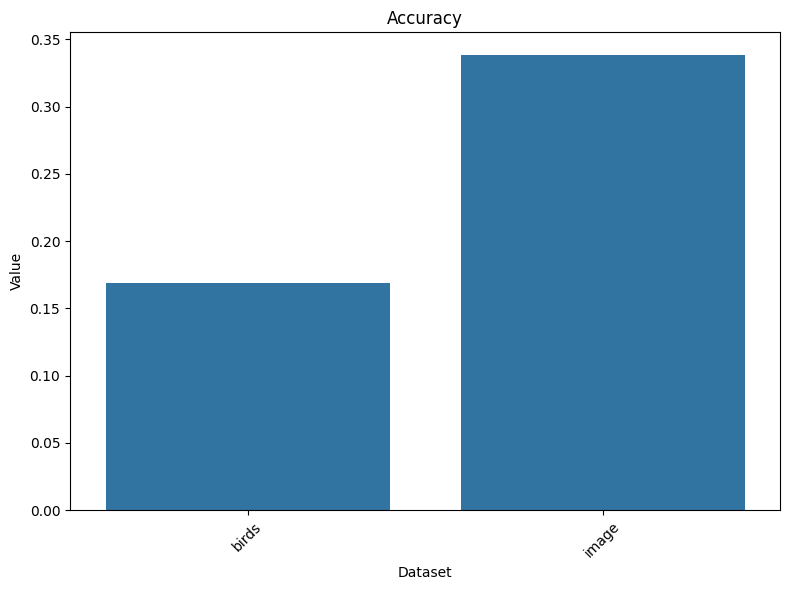

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_metric(dataframe, metric):

    plt.figure(figsize=(8, 6))

    sns.barplot(
        data=dataframe,
        x="Dataset",
        y=metric,
        errorbar=None
    )

    plt.title(metric)
    plt.xlabel("Dataset")
    plt.ylabel("Value")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


metrics_to_plot = [
    "F1 Score Macro",
    "F1 Score Micro",
    "Subset Accuracy",
    "Hamming Loss",
    "Accuracy",
]

for metric in metrics_to_plot:
    plot_metric(log, metric)

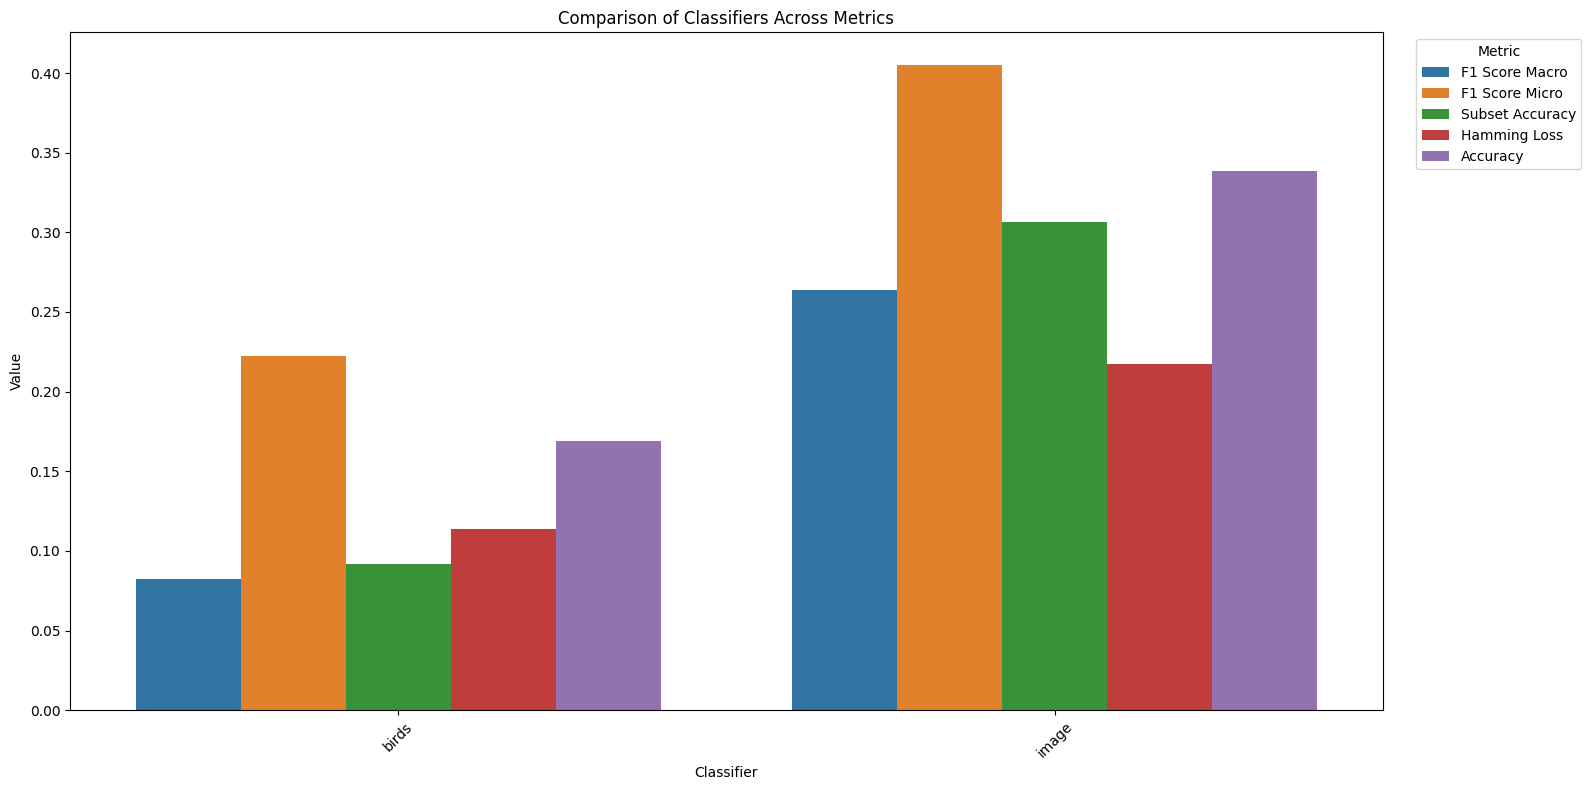

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics_to_plot = [
    "F1 Score Macro",
    "F1 Score Micro",
    "Subset Accuracy",
    "Hamming Loss",
    "Accuracy",
]

# Pasar las métricas a formato largo
plot_df = results_df.melt(
    id_vars="Dataset",
    value_vars=metrics_to_plot,
    var_name="Metric",
    value_name="Value"
)

plt.figure(figsize=(16, 8))

sns.barplot(
    data=plot_df,
    x="Dataset",
    y="Value",
    hue="Metric",
    errorbar=None
)

plt.title("Comparison of Classifiers Across Metrics")
plt.xlabel("Classifier")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()